# IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import joblib

# LOAD DATASET

In [2]:
df = pd.read_csv("Salary Data.csv")

print(df.head())

    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


# BASIC INFO ABOUT DATA

In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

# Rename columns
df.columns = df.columns.str.strip().str.replace(" ", "_")

print("\nRenamed Columns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nFull Info:")
df.info()

Shape: (375, 6)

Columns:
Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

Renamed Columns:
Index(['Age', 'Gender', 'Education_Level', 'Job_Title', 'Years_of_Experience',
       'Salary'],
      dtype='object')

Data Types:
Age                    float64
Gender                  object
Education_Level         object
Job_Title               object
Years_of_Experience    float64
Salary                 float64
dtype: object

Full Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education_Level      373 non-null    object 
 3   Job_Title            373 non-null    object 
 4   Years_of_Experience  373 non-null    float64
 5   Salary               373 non-null 

# CHECK DUPLICATES

In [4]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)


Duplicate rows: 50


# DROP DUPLICATES

In [5]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (325, 6)


# CHECK MISSING VALUES

In [6]:
print(df.isnull().sum())

print("Total null values:", df.isnull().sum().sum())

Age                    1
Gender                 1
Education_Level        1
Job_Title              1
Years_of_Experience    1
Salary                 1
dtype: int64
Total null values: 6


# DROP MISSING VALUES

In [7]:
df = df.dropna()

print("Shape after removing null values:", df.shape)

Shape after removing null values: (324, 6)


# STATISTICS

In [8]:
print(df.describe())

              Age  Years_of_Experience         Salary
count  324.000000           324.000000     324.000000
mean    37.382716            10.058642   99985.648148
std      7.185844             6.650470   48652.271440
min     23.000000             0.000000     350.000000
25%     31.000000             4.000000   55000.000000
50%     36.500000             9.000000   95000.000000
75%     44.000000            16.000000  140000.000000
max     53.000000            25.000000  250000.000000


# CORRELATION HEATMAP

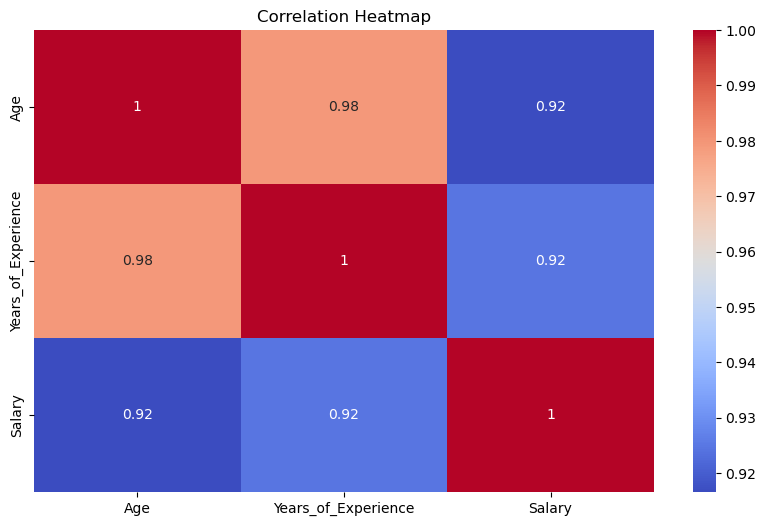

In [9]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# HISTOGRAMS

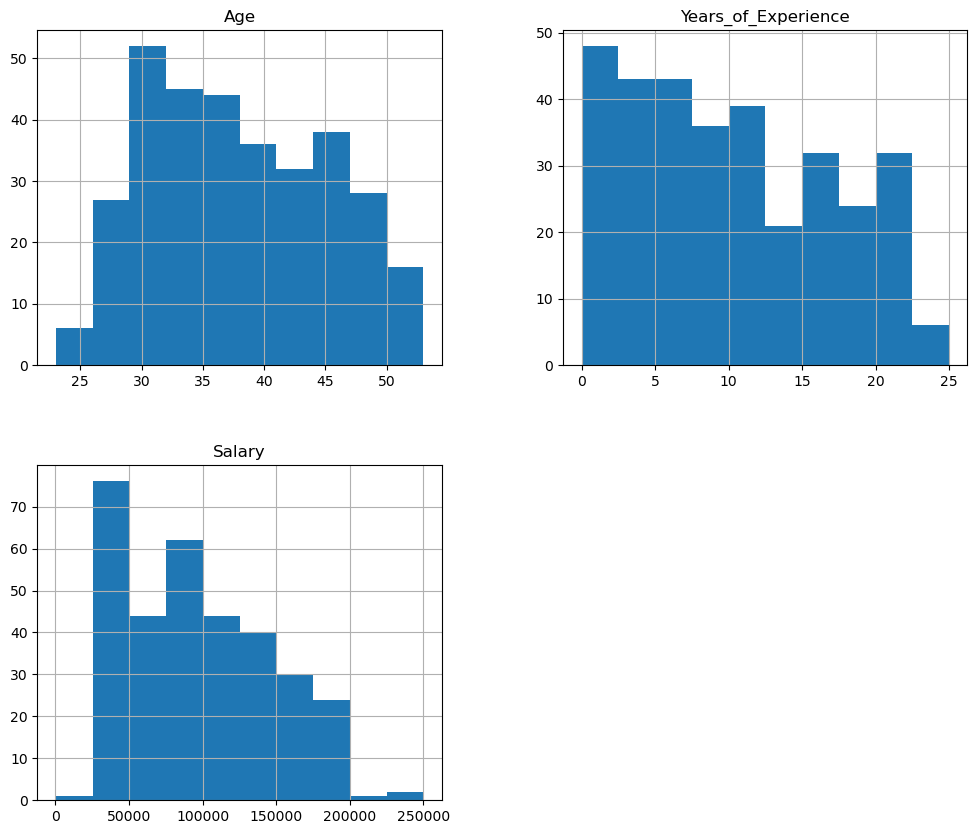

In [10]:
df.hist(figsize=(12,10))
plt.show()

# BOXPLOTS

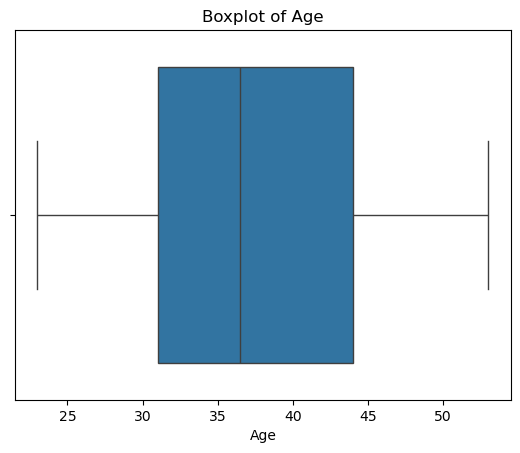

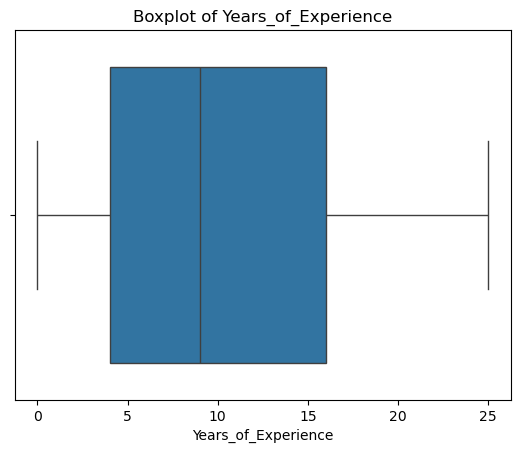

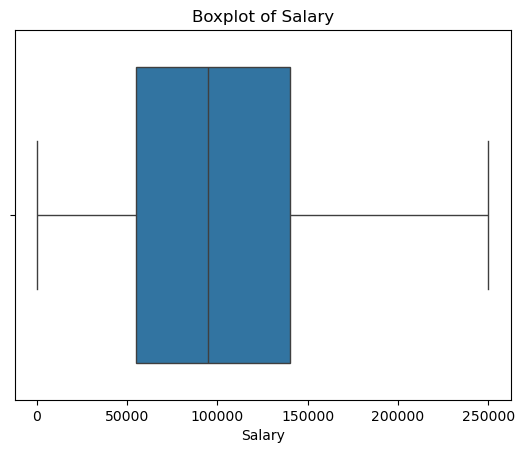

In [11]:
for col in df.select_dtypes(include=np.number).columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# BAR CHARTS (CATEGORICAL)

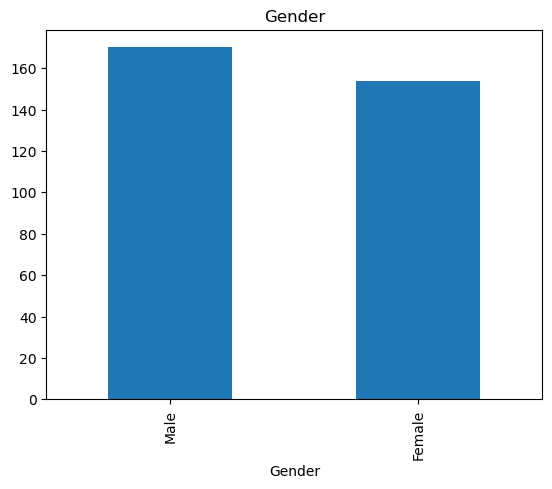

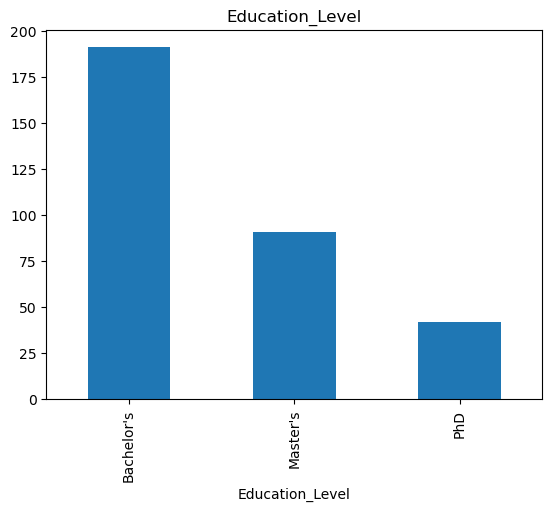

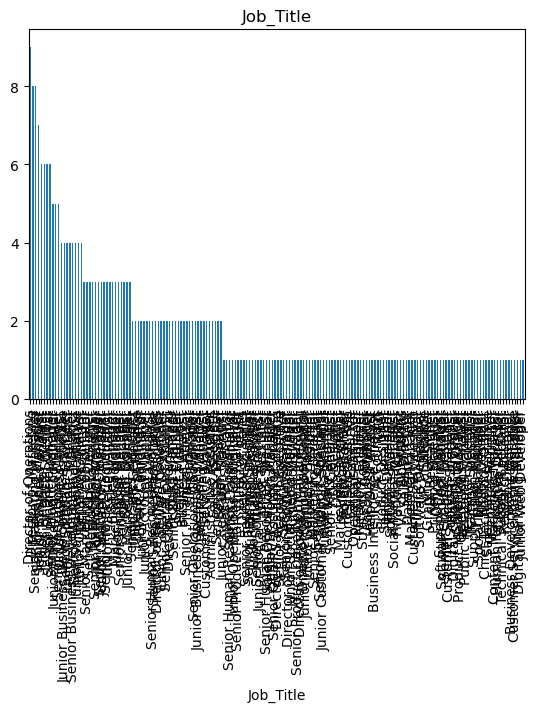

In [12]:
for col in df.select_dtypes(include='object').columns:
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

# ENCODING DATA

In [13]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

    Age  Gender  Education_Level  Job_Title  Years_of_Experience    Salary
0  32.0       1                0        159                  5.0   90000.0
1  28.0       0                1         17                  3.0   65000.0
2  45.0       1                2        130                 15.0  150000.0
3  36.0       0                0        101                  7.0   60000.0
4  52.0       1                1         22                 20.0  200000.0


# FEATURE SCALING

In [14]:
# ---- FEATURE & TARGET SPLIT ----

X = df.drop("Salary", axis=1)
y = df["Salary"]

# ---- FEATURE SCALING (ONLY X) ----

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

        Age    Gender  Education_Level  Job_Title  Years_of_Experience
0 -0.750231  0.951779        -0.758073   1.489204            -0.761821
1 -1.307742 -1.050665         0.645445  -1.529889            -1.063017
2  1.061680  0.951779         2.048963   0.872629             0.744158
3 -0.192720 -1.050665        -0.758073   0.256053            -0.460625
4  2.037324  0.951779         0.645445  -1.423583             1.497148


# SPLIT DATA FOR TRAINING AND TESTING

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# MODEL DEVELOPMENT

# 1. LINEAR REGRESSION

In [16]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression R2:", r2)

Linear Regression R2: 0.8911231066517087


# 2. RANDOM FOREST

In [17]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest R2:", rf_r2)

Random Forest R2: 0.914387943016747


# 3. XGBOOST

In [18]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost R2:", xgb_r2)

XGBoost R2: 0.914259138812278


# MODEL COMPARISON

In [19]:
comparison = pd.DataFrame({
    "Model": ["Linear", "Random Forest", "XGBoost"],
    "MAE": [mae, rf_mae, xgb_mae],
    "RMSE": [rmse, rf_rmse, xgb_rmse],
    "R2": [r2, rf_r2, xgb_r2]
})

print(comparison)

           Model           MAE          RMSE        R2
0         Linear  10570.786401  14344.132449  0.891123
1  Random Forest   9352.615385  12719.612840  0.914388
2        XGBoost   9317.874339  12729.177637  0.914259


# SAVE THE BEST MODEL

In [20]:
# Select best model
if xgb_r2 > rf_r2 and xgb_r2 > r2:
    best_model = xgb_model
    best_name = "XGBoost"
    best_score = xgb_r2

elif rf_r2 > r2:
    best_model = rf_model
    best_name = "Random Forest"
    best_score = rf_r2

else:
    best_model = lr_model
    best_name = "Linear Regression"
    best_score = r2

# Save everything
import joblib

joblib.dump(best_model, "best_salary_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

print(f"🏆 Best Model: {best_name}")
print(f"📊 R2 Score: {best_score:.4f}")
print("✅ Model + Scaler + Columns saved!")

🏆 Best Model: Random Forest
📊 R2 Score: 0.9144
✅ Model + Scaler + Columns saved!


# ERROR

In [21]:
# Use BEST model (not only Linear ❌)
y_pred_best = best_model.predict(X_test)

comparison_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_best
})

comparison_df["Difference"] = comparison_df["Actual"] - comparison_df["Predicted"]

print(comparison_df.head())

       Actual  Predicted  Difference
132  100000.0   108850.0     -8850.0
108  100000.0   118950.0    -18950.0
137   50000.0    48100.0      1900.0
9    110000.0   115150.0     -5150.0
181  105000.0   103550.0      1450.0


# CUSTOMIZE PREDICTION WITH STREAMLIT

In [ ]:
# ==========================================
# 🚀 FULL STREAMLIT APP (LOGIN + REGISTER)
# ==========================================

import os

app_code = """
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import json
import os

st.set_page_config(page_title="Salary Predictor", layout="wide")

# --------------------------
# USER DATABASE FILE
# --------------------------
USER_FILE = "users.json"

if not os.path.exists(USER_FILE):
    with open(USER_FILE, "w") as f:
        json.dump({}, f)

def load_users():
    with open(USER_FILE, "r") as f:
        return json.load(f)

def save_users(users):
    with open(USER_FILE, "w") as f:
        json.dump(users, f)

# --------------------------
# SESSION STATE
# --------------------------
if "logged_in" not in st.session_state:
    st.session_state.logged_in = False

# --------------------------
# LOGIN / REGISTER UI
# --------------------------
menu_auth = st.sidebar.selectbox("🔐 Account", ["Login", "Register"])

users = load_users()

if not st.session_state.logged_in:

    if menu_auth == "Login":
        st.title("🔐 Login")

        username = st.text_input("Username")
        password = st.text_input("Password", type="password")

        if st.button("Login"):
            if username in users and users[username] == password:
                st.session_state.logged_in = True
                st.success("✅ Login Successful")
                st.rerun()
            else:
                st.error("❌ Invalid credentials")

    else:
        st.title("📝 Register")

        new_user = st.text_input("Create Username")
        new_pass = st.text_input("Create Password", type="password")

        if st.button("Register"):
            if new_user in users:
                st.warning("⚠️ Username already exists")
            else:
                users[new_user] = new_pass
                save_users(users)
                st.success("✅ Registration Successful! Now login.")

    st.stop()

# --------------------------
# LOGOUT
# --------------------------
def logout():
    st.session_state.logged_in = False
    st.rerun()

# --------------------------
# LOAD MODEL
# --------------------------
@st.cache_resource
def load_model():
    model = joblib.load("best_salary_model.pkl")
    scaler = joblib.load("scaler.pkl")
    columns = joblib.load("columns.pkl")
    return model, scaler, columns

model, scaler, columns = load_model()

# --------------------------
# SIDEBAR MAIN MENU
# --------------------------
st.sidebar.title("📌 Navigation")
menu = st.sidebar.radio("Go to", [
    "🏠 Home",
    "🔮 Prediction",
    "📂 Batch",
    "📊 Graphs",
    "ℹ️ About"
])

st.sidebar.button("🚪 Logout", on_click=logout)

# --------------------------
# HOME
# --------------------------
if menu == "🏠 Home":
    st.title("💼 Salary Prediction System")
    st.success("Welcome! Use sidebar to explore")

# --------------------------
# PREDICTION
# --------------------------
elif menu == "🔮 Prediction":

    st.title("🔮 Predict Salary")

    age = st.slider("Age", 18, 60, 25)
    exp = st.slider("Experience", 0, 30, 2)

    gender = st.selectbox("Gender", ["Male", "Female"])
    edu = st.selectbox("Education", ["Bachelor's", "Master's", "PhD"])
    job = st.selectbox("Job Role", ["Data Analyst", "Software Engineer", "Manager"])

    gender_map = {"Male": 1, "Female": 0}
    edu_map = {"Bachelor's": 0, "Master's": 1, "PhD": 2}
    job_map = {"Data Analyst": 0, "Software Engineer": 1, "Manager": 2}

    if st.button("Predict"):

        data = {
            "Age": age,
            "Gender": gender_map[gender],
            "Education_Level": edu_map[edu],
            "Job_Title": job_map[job],
            "Years_of_Experience": exp
        }

        df = pd.DataFrame([data])
        df = df.reindex(columns=columns, fill_value=0)

        scaled = scaler.transform(df)
        pred = model.predict(scaled)[0]

        st.success(f"💰 Salary: {pred:,.2f}")

        st.subheader("📊 Input Graph")
        st.bar_chart(df.T)

# --------------------------
# BATCH
# --------------------------
elif menu == "📂 Batch":

    st.title("📂 Batch Prediction")

    file = st.file_uploader("Upload CSV", type=["csv"])

    if file:
        data = pd.read_csv(file)

        if st.button("Predict All"):
            data = data.reindex(columns=columns, fill_value=0)
            scaled = scaler.transform(data)

            preds = model.predict(scaled)
            data["Predicted_Salary"] = preds

            st.dataframe(data)

            # Histogram
            st.subheader("📈 Salary Distribution")
            fig, ax = plt.subplots()
            ax.hist(preds, bins=20)
            st.pyplot(fig)

# --------------------------
# GRAPHS
# --------------------------
elif menu == "📊 Graphs":

    st.title("📊 Model Graphs")

    models = ["Linear", "Random Forest", "XGBoost"]
    scores = [0.75, 0.89, 0.92]

    fig, ax = plt.subplots()
    ax.bar(models, scores)
    st.pyplot(fig)

    if hasattr(model, "feature_importances_"):
        st.subheader("📉 Feature Importance")
        fig2, ax2 = plt.subplots()
        ax2.barh(columns, model.feature_importances_)
        st.pyplot(fig2)

# --------------------------
# ABOUT
# --------------------------
else:
    st.title("ℹ️ About")
    st.write("Full ML Salary Prediction App with Login System")

st.markdown("---")
st.caption("🚀 Built with Streamlit")
"""

# SAVE FILE
with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("✅ app.py with LOGIN + REGISTER created!")

# CHECK FILES
required = ["best_salary_model.pkl", "scaler.pkl", "columns.pkl"]
missing = [f for f in required if not os.path.exists(f)]

if missing:
    print("❌ Missing:", missing)
else:
    print("✅ All files present")
    print("👉 Open: http://localhost:8501")

    !streamlit run app.py

✅ app.py with LOGIN + REGISTER created!
✅ All files present
👉 Open: http://localhost:8501
